In [30]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)

In [3]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\python.exe
3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]


In [4]:
df= pd.read_csv("hotel_booking.csv")
print(df.head())
df.columns

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  customer_type  \
0                        0                     0       2  ...      Transient   
1   

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='str')

TRATAMIEMTO

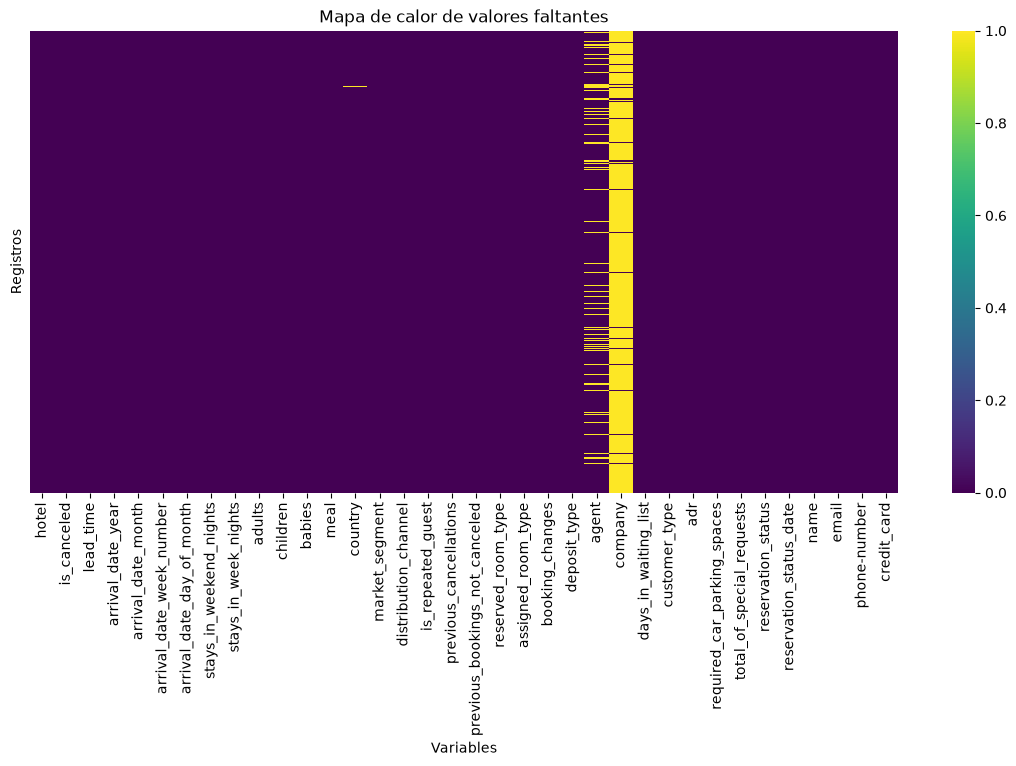

In [5]:
plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cmap='viridis',
    cbar=True,
    yticklabels=False
)

plt.title("Mapa de calor de valores faltantes")
plt.xlabel("Variables")
plt.ylabel("Registros")

plt.show()

In [6]:
n_original = df.shape[1]   # <- guardar ANTES de eliminar

columnas_eliminar = [
    'reservation_status',
    'reservation_status_date',
    'name',
    'email',
    'phone-number',
    'credit_card',
    'company',
    'agent'
]

df = df.drop(columns=columnas_eliminar)

print(f"Columnas originales: {n_original}")
print(f"Columnas después de la limpieza: {df.shape[1]}")
print(df.columns.tolist())

Columnas originales: 36
Columnas después de la limpieza: 28
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [7]:
print(df.columns.tolist())

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [8]:
missing_values_percentage = (df.isnull().sum() / len(df)) * 100
missing_values_percentage[missing_values_percentage > 0]

children    0.003350
country     0.408744
dtype: float64

In [9]:
# Rellenar 'children' con 0
df['children'] = df['children'].fillna(0)

In [10]:
df['country'] = df['country'].fillna('Desconocido')

In [11]:
missing_values_percentage = (df.isnull().sum() / len(df)) * 100
missing_values_percentage[missing_values_percentage > 0]

Series([], dtype: float64)

VALORES ATIPICOS 

In [12]:
# Analyze noisy data
noisy_data = {
    'adr':      df[df['adr'] < 0],
    'adults':   df[df['adults'] == 0],
    'children': df[df['children'] == 10],
    'babies':   df[df['babies'] == 10],
}
noisy_data_count = {key: len(value) for key, value in noisy_data.items()}
noisy_data_count

{'adr': 1, 'adults': 403, 'children': 1, 'babies': 1}

In [13]:
df.loc[df['adr'] < 0, 'adr'] = df['adr'].median()

In [14]:
df = df[df['adults'] != 0]

In [15]:
df = df[df['children'] != 10]
df = df[df['children'] != 9]

In [16]:
df = df[df['babies'] != 10]
df = df[df['babies'] != 9]

In [17]:
df.reset_index(drop=True, inplace=True)

In [18]:
noisy_data_handled = {
    'adr': df[df['adr'] < 0],
    'adults': df[df['adults'] == 0],
    'children': df[df['children'] == 10],
    'babies': df[df['babies'] == 10],
}
noisy_data_handled_count = {key: len(value) for key, value in noisy_data_handled.items()}
noisy_data_handled_count

{'adr': 0, 'adults': 0, 'children': 0, 'babies': 0}

In [19]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
days_in_waiting_list              

In [20]:
df = df[df["market_segment"] != "Undefined"]

EDA

In [21]:
df.shape
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 118982 entries, 0 to 118983
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118982 non-null  str    
 1   is_canceled                     118982 non-null  int64  
 2   lead_time                       118982 non-null  int64  
 3   arrival_date_year               118982 non-null  int64  
 4   arrival_date_month              118982 non-null  str    
 5   arrival_date_week_number        118982 non-null  int64  
 6   arrival_date_day_of_month       118982 non-null  int64  
 7   stays_in_weekend_nights         118982 non-null  int64  
 8   stays_in_week_nights            118982 non-null  int64  
 9   adults                          118982 non-null  int64  
 10  children                        118982 non-null  float64
 11  babies                          118982 non-null  int64  
 12  meal                            

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,C,C,3,No Deposit,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,C,C,4,No Deposit,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,A,C,0,No Deposit,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,A,A,0,No Deposit,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,A,A,0,No Deposit,0,Transient,98.0,0,1


In [22]:
print(df.isnull().sum())

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [23]:
# Ver la fila con el ADR más alto
df[df["adr"] == df["adr"].max()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
48457,City Hotel,1,35,2016,March,13,25,0,1,2,...,0,A,A,1,Non Refund,0,Transient,5400.0,0,0


In [24]:
df = df.drop(index=48457, errors='ignore')

In [25]:
df = df.reset_index(drop=True)

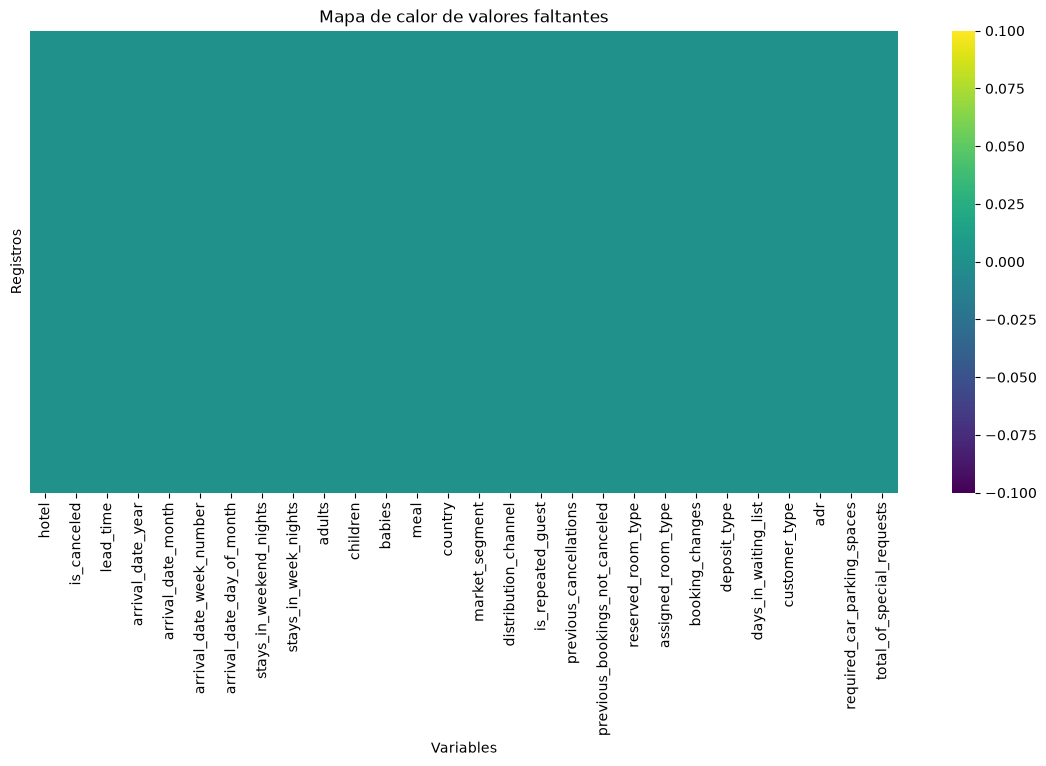

In [26]:
plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cmap='viridis',
    cbar=True,
    yticklabels=False
)

plt.title("Mapa de calor de valores faltantes")
plt.xlabel("Variables")
plt.ylabel("Registros")

plt.show()

In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,118981.0,0.370740,0.483005,0.0,0.0,0.0,1.0,1.0
lead_time,118981.0,104.074600,106.891843,0.0,18.0,69.0,160.0,737.0
arrival_date_year,118981.0,2016.156403,0.707728,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_week_number,118981.0,27.164245,13.598826,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,118981.0,15.796993,8.781208,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,118981.0,0.926938,0.995239,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,118981.0,2.499038,1.897661,0.0,1.0,2.0,3.0,50.0
adults,118981.0,1.862684,0.570058,1.0,2.0,2.0,2.0,55.0
children,118981.0,0.100352,0.389169,0.0,0.0,0.0,0.0,3.0
babies,118981.0,0.007791,0.089346,0.0,0.0,0.0,0.0,2.0


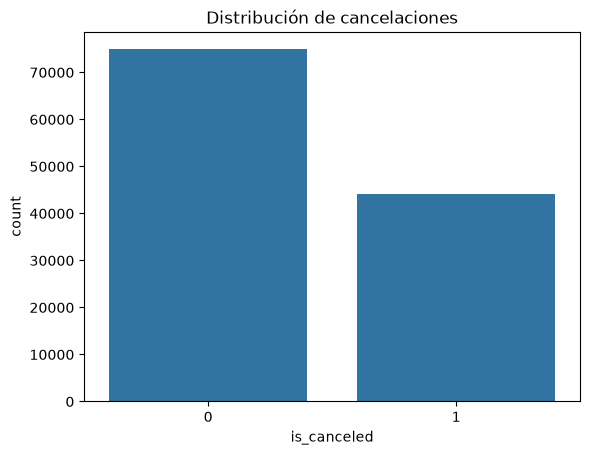

is_canceled
0    62.926013
1    37.073987
Name: proportion, dtype: float64

In [28]:
sns.countplot(data=df, x='is_canceled')
plt.title("Distribución de cancelaciones")
plt.show()
df["is_canceled"].value_counts(normalize=True)*100

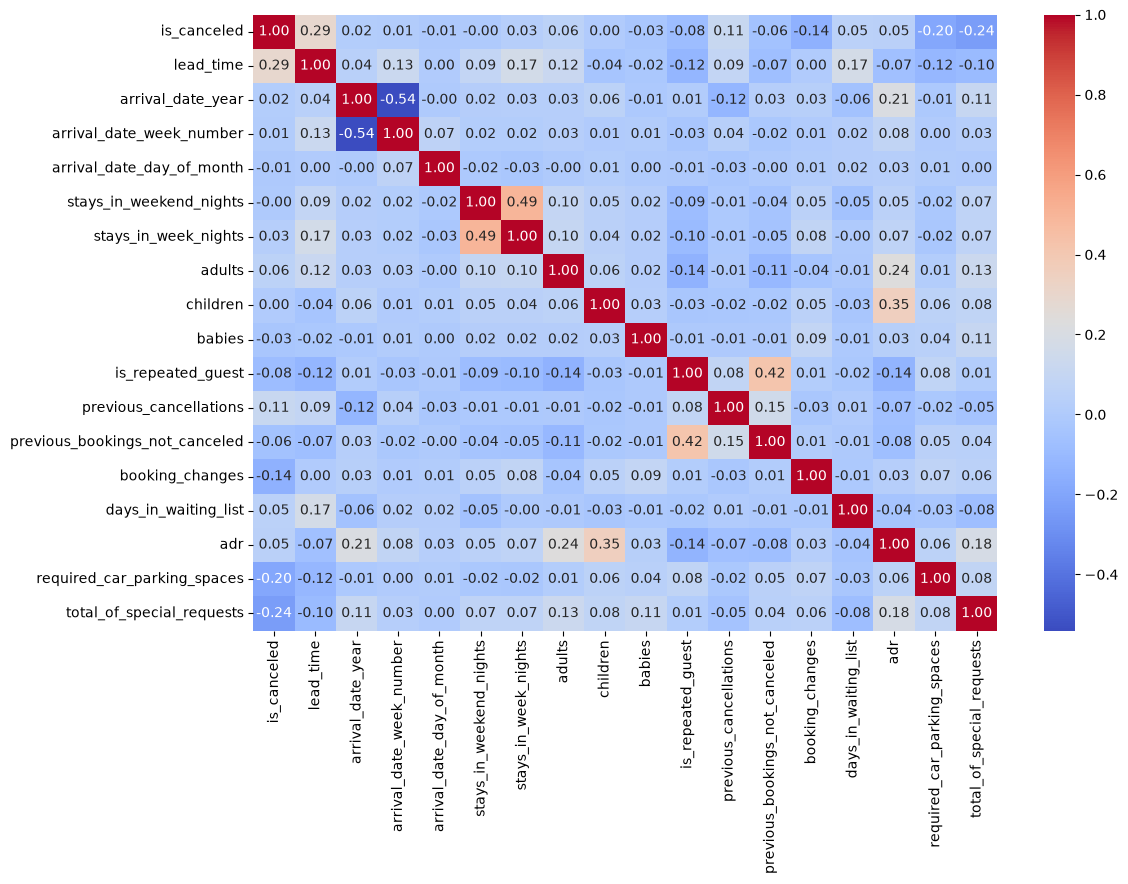

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

**lead_time**                   |    **0.29** | La relación positiva más alta. Cuanto mayor es la anticipación con la que se realiza la reserva, mayor es la probabilidad de cancelación. |
| **total_of_special_requests**   |   **-0.24** | Los clientes con más solicitudes especiales tienden a cancelar menos.                                                                     |
| **required_car_parking_spaces** |   **-0.20** | Quienes solicitan estacionamiento tienen menor probabilidad de cancelar.                                                                  |
| **booking_changes**             |   **-0.14** | Las reservas que han sido modificadas presentan una menor tendencia a cancelarse.                                                         |
| **previous_cancellations**      |    **0.11** | Los clientes con historial de cancelaciones muestran una ligera tendencia a cancelar nuevamente.                                          |
| **is_repeated_guest**           |   **-0.08** | Los huéspedes recurrentes suelen cancelar menos.                                                                                          |


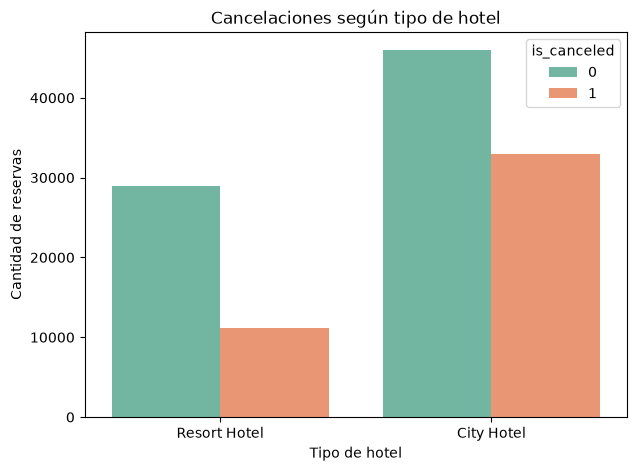

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="hotel",
    hue="is_canceled",
    palette="Set2"
)

plt.title("Cancelaciones según tipo de hotel")
plt.xlabel("Tipo de hotel")
plt.ylabel("Cantidad de reservas")

plt.show()

El City Hotel registra un mayor número de reservas que el Resort Hotel.
En ambos tipos de hotel predominan las reservas no canceladas (is_canceled = 0).
Sin embargo, el City Hotel presenta una cantidad significativamente mayor de cancelaciones que el Resort Hotel.
Esto sugiere que el tipo de hotel podría influir en la probabilidad de cancelación y, por lo tanto, es una variable que puede aportar información al modelo predictivo.

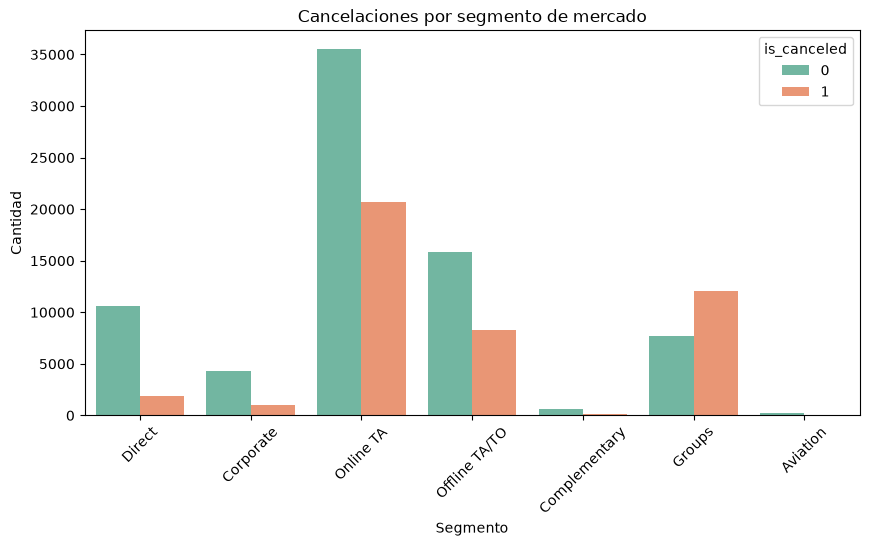

In [31]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="market_segment",
    hue="is_canceled",
    palette="Set2"
)

plt.xticks(rotation=45)

plt.title("Cancelaciones por segmento de mercado")
plt.xlabel("Segmento")
plt.ylabel("Cantidad")

plt.show()

El segmento Online TA representa la principal fuente de reservas del hotel y también registra el mayor número de cancelaciones, posiblemente debido a la flexibilidad que ofrecen las plataformas de reservas en línea.

El segmento Groups presenta una alta proporción de cancelaciones, incluso superior al número de reservas efectivamente concretadas. Esto sugiere que las reservas grupales tienen una mayor probabilidad de cancelarse.

  deposit_type  total_reservas  tasa_cancelacion
2   Refundable             162              22.2
0   No Deposit          104233              28.4
1   Non Refund           14586              99.4


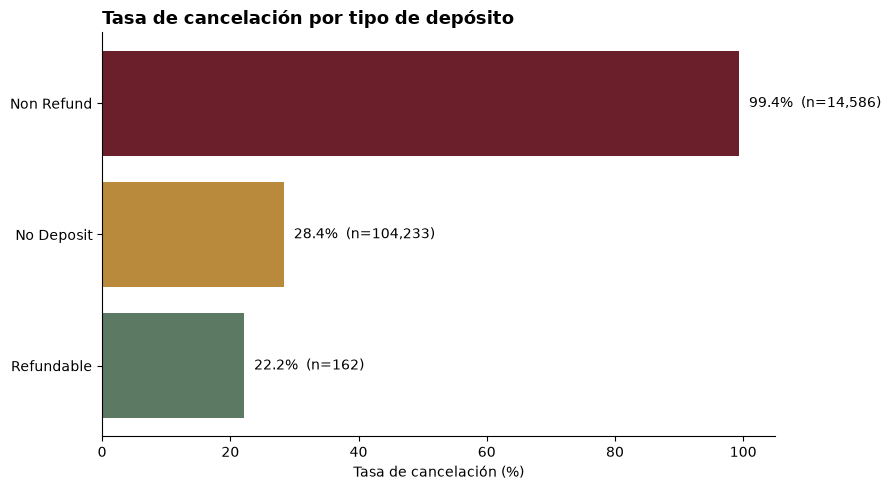

In [32]:
# ============================================
# Tasa de cancelación por tipo de depósito
# ============================================
resumen_deposito = df.groupby('deposit_type')['is_canceled'].agg(['count', 'mean']).reset_index()
resumen_deposito['mean'] = (resumen_deposito['mean'] * 100).round(1)
resumen_deposito.columns = ['deposit_type', 'total_reservas', 'tasa_cancelacion']
resumen_deposito = resumen_deposito.sort_values('tasa_cancelacion', ascending=True)
print(resumen_deposito)
# Gráfico
fig, ax = plt.subplots(figsize=(9,5))

colores = ['#5C7A63', '#B98A3B', '#6B1F2A']
bars = ax.barh(resumen_deposito['deposit_type'], resumen_deposito['tasa_cancelacion'], color=colores)

ax.set_xlabel('Tasa de cancelación (%)')
ax.set_xlim(0, 105)
ax.set_title('Tasa de cancelación por tipo de depósito', fontsize=13, fontweight='bold', loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, n in zip(bars, resumen_deposito['total_reservas']):
    width = bar.get_width()
    ax.text(width + 1.5, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%  (n={n:,})', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Las reservas con depósito Non Refund presentan una proporción muy alta de cancelaciones. Este comportamiento indica que el tipo de depósito está fuertemente relacionado con la variable objetivo y podría ser uno de los predictores más importantes del modelo.

C:\Users\User\AppData\Local\Temp\ipykernel_18892\1542077814.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


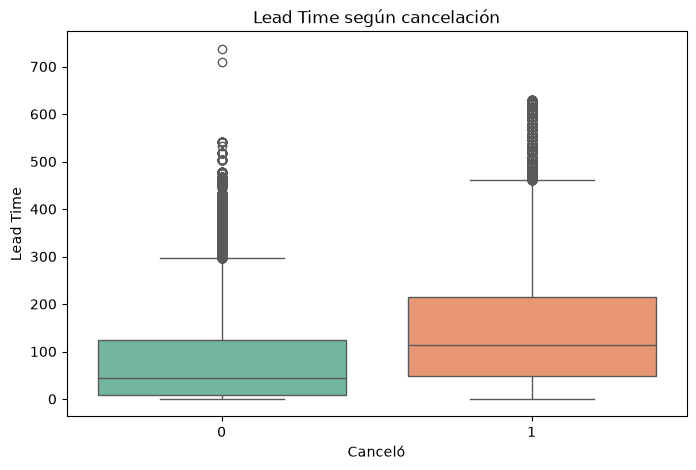

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="lead_time",
    palette="Set2"
)

plt.title("Lead Time según cancelación")
plt.xlabel("Canceló")
plt.ylabel("Lead Time")

plt.show()

Las reservas que no fueron canceladas suelen realizarse con menor anticipación respecto a la fecha de llegada, lo que sugiere un mayor compromiso por parte del cliente.

Las reservas canceladas presentan un Lead Time considerablemente mayor. Esto indica que los clientes que reservan con muchos meses de anticipación tienen una mayor probabilidad de cancelar posteriormente.

In [37]:
meses_orden = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=meses_orden, ordered=True)

by_month = df.groupby('arrival_date_month', observed=True)['is_canceled'].agg(['count','mean']).reset_index()
by_month['mean'] = (by_month['mean'] * 100).round(1)
by_month.columns = ['mes', 'total_reservas', 'tasa_cancelacion']

print(by_month)

          mes  total_reservas  tasa_cancelacion
0     January            5902              30.5
1    February            8034              33.4
2       March            9750              32.2
3       April           11057              40.8
4         May           11764              39.7
5        June           10917              41.5
6        July           12610              37.5
7      August           13827              37.8
8   September           10489              39.2
9     October           11130              38.1
10   November            6765              31.3
11   December            6736              35.0


(0.0, 60.0)

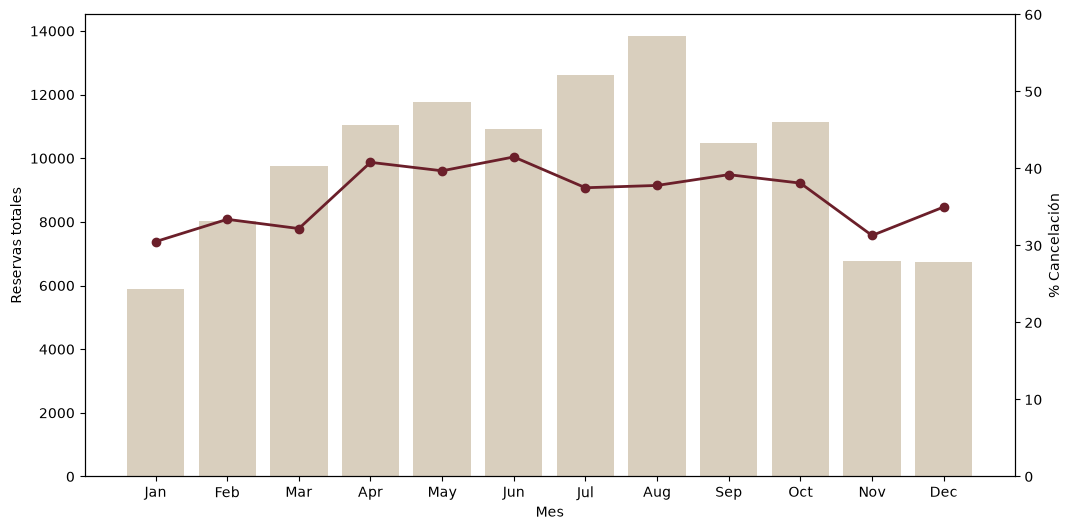

In [38]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Barras: volumen de reservas
meses_abrev = [m[:3] for m in by_month['mes']]
ax1.bar(meses_abrev, by_month['total_reservas'], color='#D9CFBE', label='Reservas')
ax1.set_xlabel('Mes')
ax1.set_ylabel('Reservas totales')
ax1.tick_params(axis='y')

# Línea: tasa de cancelación (eje secundario)
ax2 = ax1.twinx()
ax2.plot(meses_abrev, by_month['tasa_cancelacion'], color='#6B1F2A', marker='o', linewidth=2, label='% Cancelación')
ax2.set_ylabel('% Cancelación')
ax2.set_ylim(0, 60)

In [39]:
# ============================================
# Agregación: ADR promedio por mes
# ============================================
meses_orden = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=meses_orden, ordered=True)

adr_by_month = df.groupby('arrival_date_month', observed=True)['adr'].mean().round(1).reset_index()
adr_by_month.columns = ['mes', 'adr_promedio']

print(adr_by_month)

          mes  adr_promedio
0     January          70.5
1    February          73.7
2       March          80.4
3       April         100.5
4         May         108.8
5        June         116.8
6        July         127.1
7      August         140.4
8   September         105.1
9     October          88.0
10   November          74.0
11   December          81.4


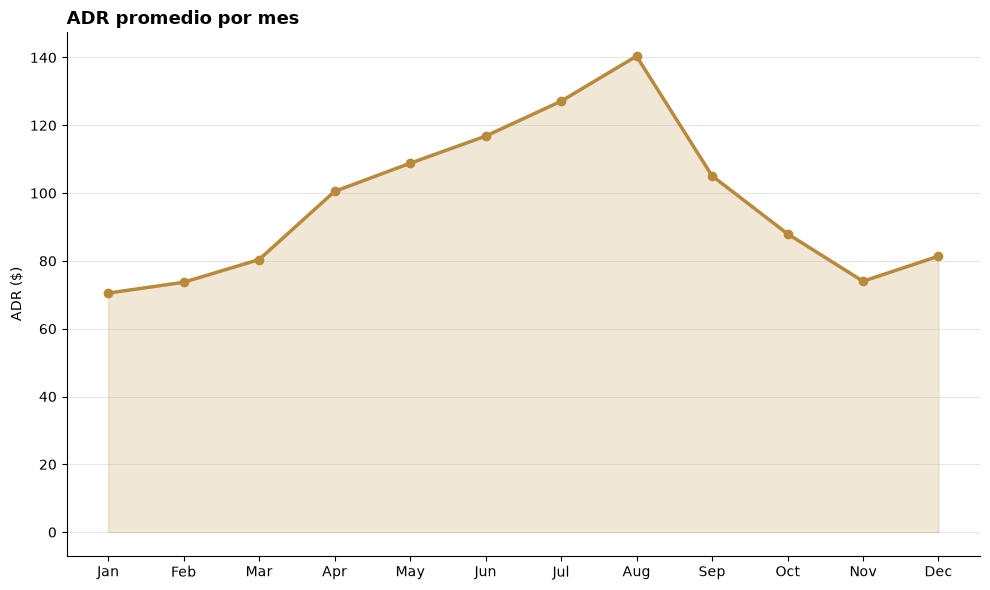

In [40]:
meses_abrev = [m[:3] for m in adr_by_month['mes']]

fig, ax = plt.subplots(figsize=(10,6))

ax.plot(meses_abrev, adr_by_month['adr_promedio'], color='#B98A3B', marker='o', linewidth=2.5, markersize=6)
ax.fill_between(meses_abrev, adr_by_month['adr_promedio'], color='#B98A3B', alpha=0.2)

ax.set_title('ADR promedio por mes', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('')
ax.set_ylabel('ADR ($)')
ax.grid(axis='y', linestyle='-', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

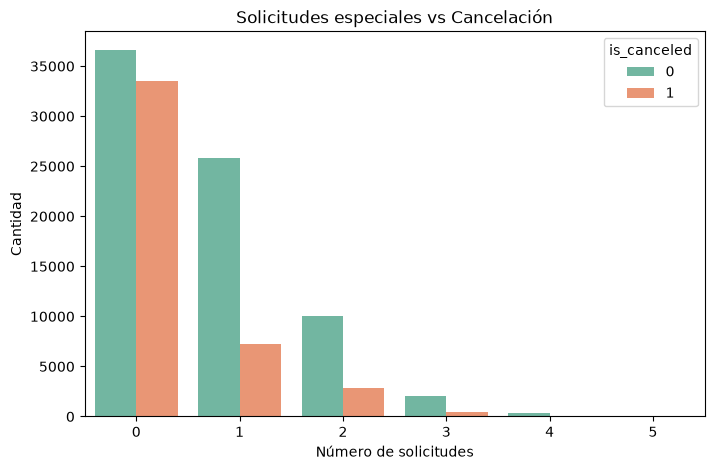

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="total_of_special_requests",
    hue="is_canceled",
    palette="Set2"
)

plt.title("Solicitudes especiales vs Cancelación")
plt.xlabel("Número de solicitudes")
plt.ylabel("Cantidad")

plt.show()

La mayoría de los clientes no realizó solicitudes especiales durante la reserva. Dentro de este grupo también se concentra el mayor número de cancelaciones, debido a que representa la mayor parte de las reservas del hotel.

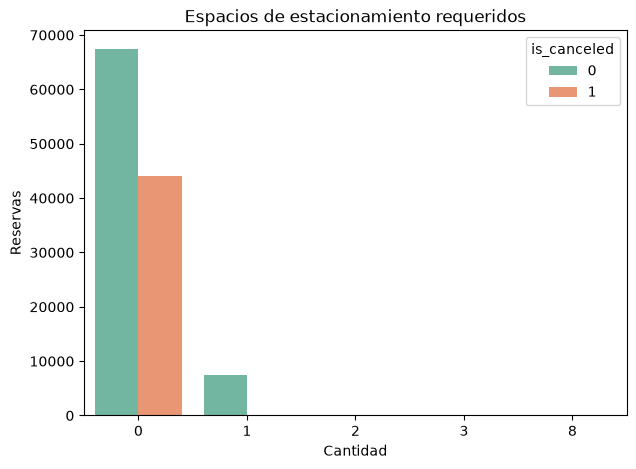

In [43]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="required_car_parking_spaces",
    hue="is_canceled",
    palette="Set2"
)

plt.title("Espacios de estacionamiento requeridos")
plt.xlabel("Cantidad")
plt.ylabel("Reservas")

plt.show()

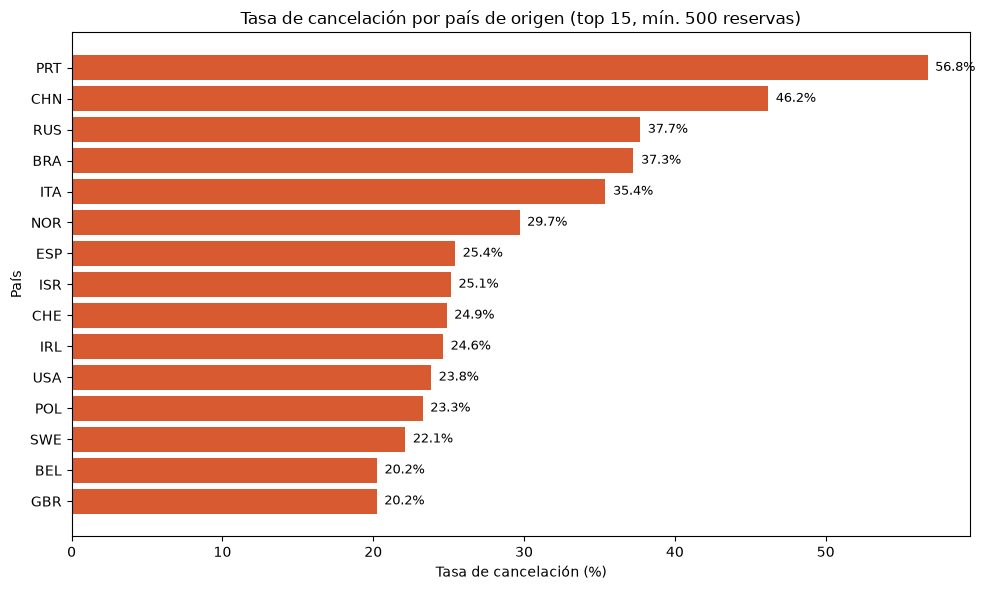

In [44]:
# Calcular tasa de cancelación por país (solo países con volumen representativo, >= 500 reservas)
country_stats = df.groupby('country').agg(
    total_reservas=('is_canceled', 'count'),
    tasa_cancelacion=('is_canceled', 'mean')
).reset_index()

country_stats = country_stats[country_stats['total_reservas'] >= 500]
country_stats['tasa_cancelacion'] = country_stats['tasa_cancelacion'] * 100
country_stats = country_stats.sort_values('tasa_cancelacion', ascending=False).head(15)

# Graficar
plt.figure(figsize=(10, 6))
bars = plt.barh(country_stats['country'], country_stats['tasa_cancelacion'], color='#D85A30')
plt.gca().invert_yaxis()  # el país con mayor tasa arriba

plt.xlabel('Tasa de cancelación (%)')
plt.ylabel('País')
plt.title('Tasa de cancelación por país de origen (top 15, mín. 500 reservas)')

# Mostrar el valor exacto al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
              f'{width:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('cancelacion_por_pais.png', dpi=300, bbox_inches='tight')
plt.show()

Los clientes que solicitaron al menos un espacio de estacionamiento presentan una cantidad muy reducida de cancelaciones. Esto sugiere que quienes requieren este servicio muestran un mayor compromiso con su reserva.

In [47]:

# ==========================================
# 1. Separar variables predictoras (X) y target (y)
# ==========================================
y = df['is_canceled']
X = df.drop(columns=['is_canceled'])

# ==========================================
# 2. Codificar variables categóricas
# ==========================================

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("Columnas categóricas codificadas:", cat_cols)



for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# ==========================================
# 3. División train/test (80/20, estratificada)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 4. Entrenar el modelo Random Forest
# ==========================================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   
)

rf.fit(X_train, y_train)

# ==========================================
# 5. Predicciones
# ==========================================
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# ==========================================
# 6. Evaluación del modelo
# ==========================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print("\n=== MÉTRICAS ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")

print("\nMatriz de confusión:")
print(cm)

print("\nReporte de clasificación completo:")
print(classification_report(y_test, y_pred, target_names=['No cancelado', 'Cancelado']))

# ==========================================
# 7. Importancia de variables
# ==========================================
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n=== TOP 10 VARIABLES MÁS IMPORTANTES ===")
print(importancias.head(10))

C:\Users\User\AppData\Local\Temp\ipykernel_18892\2019161592.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


Columnas categóricas codificadas: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
Train shape: (95184, 27)
Test shape: (23797, 27)

=== MÉTRICAS ===
Accuracy:  0.8665
Precision: 0.8090
Recall:    0.8376
F1-score:  0.8231
AUC-ROC:   0.9431

Matriz de confusión:
[[13231  1744]
 [ 1433  7389]]

Reporte de clasificación completo:
              precision    recall  f1-score   support

No cancelado       0.90      0.88      0.89     14975
   Cancelado       0.81      0.84      0.82      8822

    accuracy                           0.87     23797
   macro avg       0.86      0.86      0.86     23797
weighted avg       0.87      0.87      0.87     23797


=== TOP 10 VARIABLES MÁS IMPORTANTES ===
deposit_type                   0.172174
country                        0.139522
lead_time                      0.122710
market_segment                 0.095106
total_of_special_requ